Temurjon Ismailov 
10/17/2024 

Project 1 Part 3. Data Analysis and Visualization

Import pandas library.

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

Import each CSV

In [107]:
df1 = pd.read_csv(r'C:\Users\sbani\Desktop\Coding stuff\Data science\Notebooks\Majors_2024_Cleaned.csv')


Print out the data files to ensure they were correctly imported. (commented out after testing to reduce clutter.)

In [ ]:
print(df1.head())

What are the major motivations why computing majors seek a computing degree/certificate?

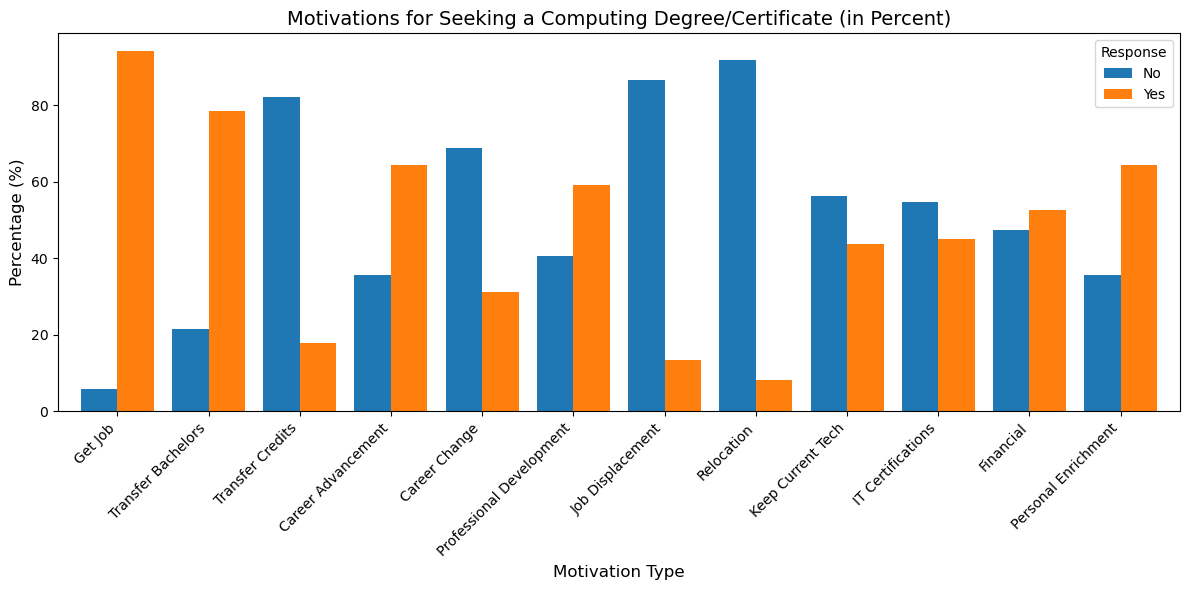

In [101]:
#Create a list of columns that deal with motivation
motivation_columns = [
    'motivation_get_job_computing',
    'motivation_transfer_bachelors',
    'motivation_transfer_credits_hs',
    'motivation_career_advancement',
    'motivation_career_change',
    'motivation_professional_dev',
    'motivation_job_displacement',
    'motivation_relocation',
    'motivation_keep_current_tech',
    'motivation_it_certifications',
    'motivation_financial',
    'motivation_personal_enrichment'
]
#Count the number of times different motivators were cited. 

motivation_counts = {}
for col in motivation_columns:
    motivation_counts[col] = df1[col].value_counts()

#Convert motivation_count dictionary to a dataframe
df_motivations = pd.DataFrame(motivation_counts)

#Create a plot of the data using matplotlib
df_motivations = df_motivations.T   #This transposes the df, swapping rows and columns. Needed for graph to come out propely. 

# Calculate the percentage for each motivation
totals = df_motivations.sum(axis=1)
df_percentages = df_motivations.div(totals, axis=0) * 100

# Plotting
bar_width = 0.8  # Control bar width
ax = df_percentages.plot(kind='bar', figsize=(12, 6), width=bar_width)


ax.set_title('Motivations for Seeking a Computing Degree/Certificate (in Percent)', fontsize=14)
ax.set_xlabel('Motivation Type', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)

x_labels = [
    'Get Job', 'Transfer Bachelors', 'Transfer Credits', 'Career Advancement', 
    'Career Change', 'Professional Development', 'Job Displacement', 
    'Relocation', 'Keep Current Tech', 'IT Certifications', 
    'Financial', 'Personal Enrichment'
]

ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)

# Adjust legend and layout
plt.legend(title='Response', fontsize=10)
plt.tight_layout()  # Adjust layout for better fit
plt.show()

Get a job, Transfer Bachelors, Cafeer Advacement, professional development, financial and personal enrichment were all cited by the majority of respondents. Analysis indicates that increasing the number of classes focused on these areas could boost enrollment.

What was the most and least common source of advertisement that lead to a student enrolling in a class? 

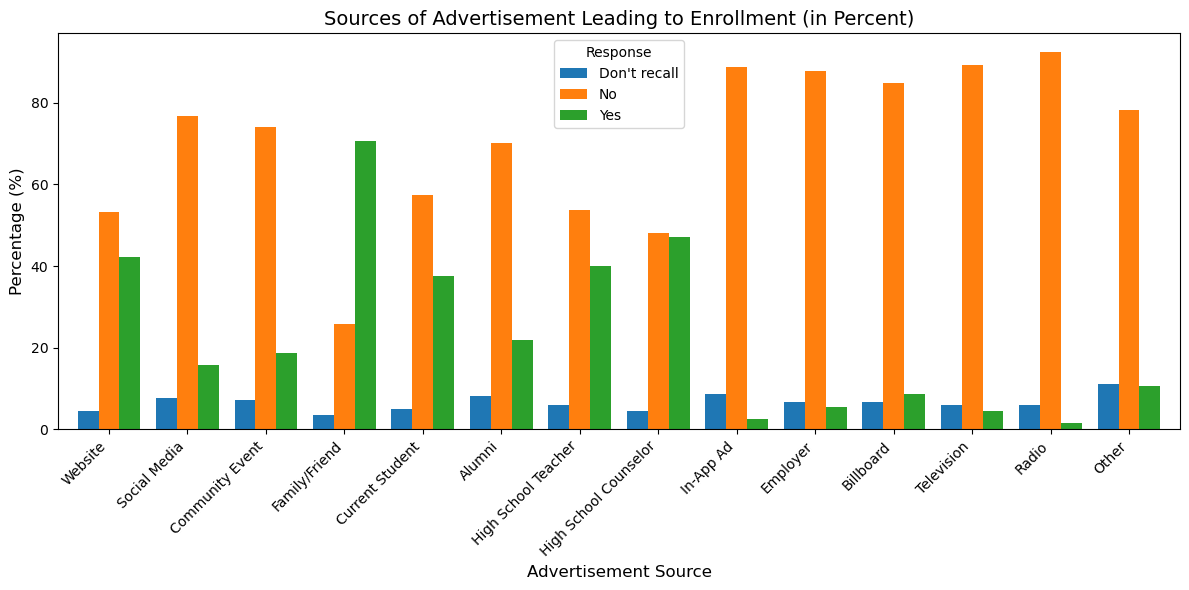

In [33]:
ad_columns = [
    'heard_about_CCM_website',
    'heard_about_CCM_social_media',
    'heard_about_CCM_community_event',
    'heard_about_CCM_family_friend',
    'heard_about_CCM_current_student',
    'heard_about_CCM_alumni',
    'heard_about_CCM_high_school_teacher',
    'heard_about_CCM_high_school_counselor',
    'heard_about_CCM_in_app_ad',
    'heard_about_CCM_employer',
    'heard_about_CCM_billboard',
    'heard_about_CCM_television',
    'heard_about_CCM_radio',
    'heard_about_CCM_other'
]

#Count the number of times different ads were cited.
ad_counts = {}
for col in ad_columns:
    ad_counts[col] = df1[col].value_counts()

#Convert motivation_count dictionary to a dataframe
df_ads = pd.DataFrame(ad_counts)

df_ads = df_ads.T   
# Calculate the percentage for each ad
totals = df_ads.sum(axis=1)
df_percentages = df_ads.div(totals, axis=0) * 100

# Plotting
bar_width = 0.8 
ax = df_percentages.plot(kind='bar', figsize=(12, 6), width=bar_width)

ax.set_title('Sources of Advertisement Leading to Enrollment (in Percent)', fontsize=14)
ax.set_xlabel('Advertisement Source', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)

x_labels = [
    'Website',
    'Social Media',
    'Community Event',
    'Family/Friend',
    'Current Student',
    'Alumni',
    'High School Teacher',
    'High School Counselor',
    'In-App Ad',
    'Employer',
    'Billboard',
    'Television',
    'Radio',
    'Other'
]
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=10)

plt.legend(title='Response', fontsize=10)
plt.tight_layout()  
plt.show()


Family/friends, the CCM website, high school teachers, current students, and high school counselors are the top sources where people heard of County College of Morris. This suggests we should enhance outreach through these channels to boost enrollment.

Which introductory class students were most likely to take more classes? 

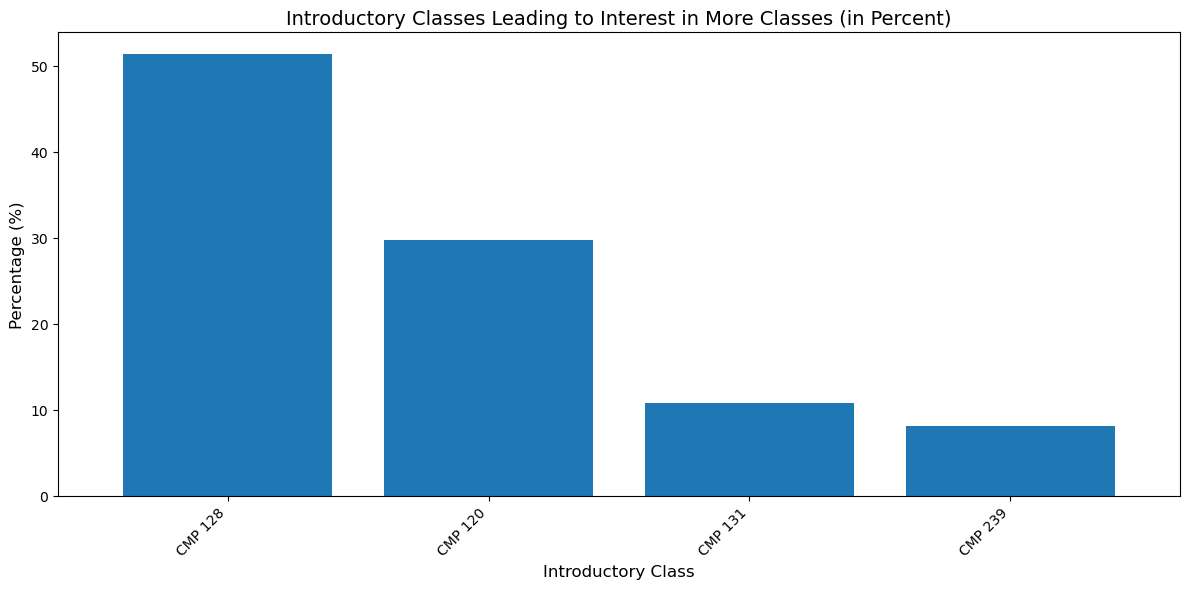

In [87]:
# Filter for students indicating a score of 4 or greater for interest in more computing classes
int_std = df1['interest_more_computing_classes']
students_interested = df1[int_std >= 4] 

# Count occurrences of each introductory class in the specified column
intro_counts = students_interested['course_enrolled'].value_counts()
#print(intro_counts)

# Create a DataFrame to work with percentages
df_intro = intro_counts.reset_index()  
df_intro.columns = ['Introductory Class', 'Count']  

# Calculate percentages
total_students = df_intro['Count'].sum()
df_intro['Percentage (%)'] = (df_intro['Count'] / total_students) * 100

# Plotting
bar_width = 0.8  
ax_intro = df_intro.plot(kind='bar', x='Introductory Class', y='Percentage (%)', figsize=(12, 6), width=bar_width)

neat_labels = ['CMP 128', 'CMP 120', 'CMP 131', 'CMP 239'] 
ax_intro.set_xticklabels(neat_labels, rotation=45, ha='right', fontsize=10)

ax_intro.set_title('Introductory Classes Leading to Interest in More Classes (in Percent)', fontsize=14)
ax_intro.set_xlabel('Introductory Class', fontsize=12)
ax_intro.set_ylabel('Percentage (%)', fontsize=12)

ax_intro.legend_.set_visible(False)  

plt.tight_layout() 
plt.show()

The analysis reveals that 50% of the most enthusiastic students wanting to take more classes are from CMP 128 Computer Science I, while other introductory courses exhibit significantly less enthusiasm. Notably, CMP 130 had 0% enthusiastic students.

To foster greater enthusiasm across all introductory classes, it's essential to better support students in these courses. Enhancing resources, mentorship, and engagement strategies could lead to increased interest and participation in computing classes overall.

Which programs have the most students intrested in taking more classes? 

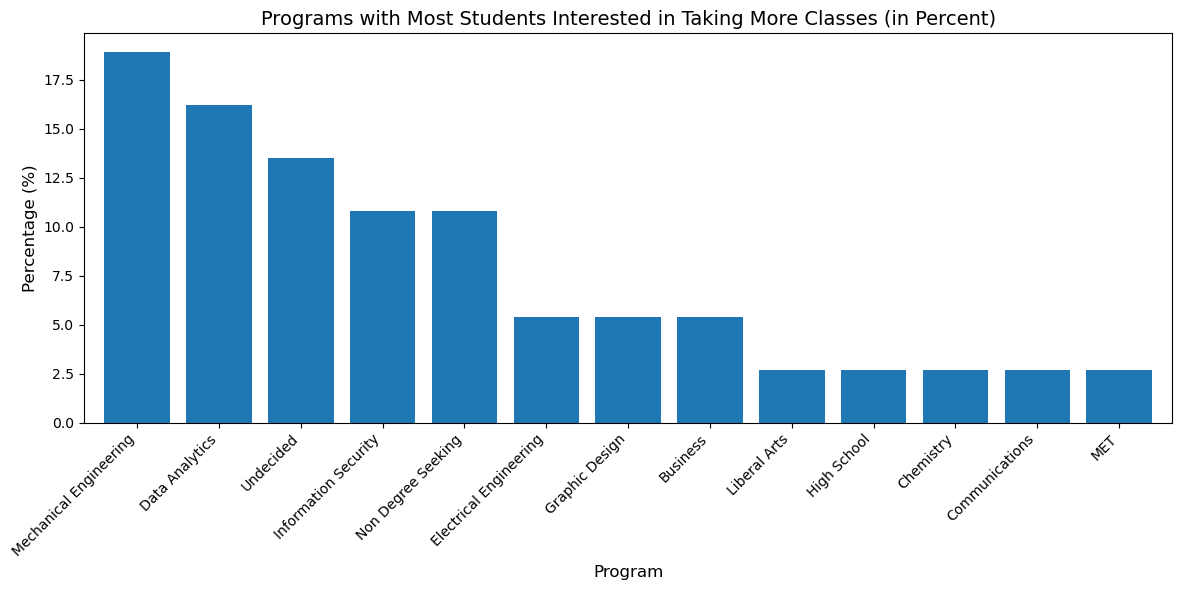

In [109]:
# Filter for students indicating a score of 4 or greater for interest in more computing classes
int_std = df1['interest_more_computing_classes']
students_interested = df1[int_std >= 4]

program_counts = students_interested['current_degree_program'].value_counts()  

# Create a DataFrame to work with percentages
df_programs = program_counts.reset_index()  
df_programs.columns = ['Program', 'Count']  

# Calculate percentages
total_students = df_programs['Count'].sum()
df_programs['Percentage (%)'] = (df_programs['Count'] / total_students) * 100

# Plotting
bar_width = 0.8  
ax_programs = df_programs.plot(kind='bar', x='Program', y='Percentage (%)', figsize=(12, 6), width=bar_width)

ax_programs.set_title('Programs with Most Students Interested in Taking More Classes (in Percent)', fontsize=14)
ax_programs.set_xlabel('Program', fontsize=12)
ax_programs.set_ylabel('Percentage (%)', fontsize=12)

# Neat labels for x-axis
ax_programs.set_xticklabels(df_programs['Program'], rotation=45, ha='right', fontsize=10)

# Remove the legend since only one bar
ax_programs.legend_.set_visible(False)  

plt.tight_layout() 
plt.show()

Mechanical Engineering, Data Analytics, Undecideds, and Information Security have the highest share of enthusiastic students interested in taking more classes. To enhance student engagement and success, the department should consider tailoring future course offerings and support services to align with these interests.